In [5]:
!pip install xgboost imbalanced-learn

**1. Import Library**

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Feature selection
from sklearn.feature_selection import SelectKBest, f_classif

# Balancing
from imblearn.over_sampling import SMOTE

In [4]:
import pandas as pd

df = pd.read_csv('/content/University Student Mental Health Indicators Dataset.csv')

df.head()

,PHQ9,GAD7,SleepHours,ExerciseFreq,SocialActivity,OnlineStress,GPA,FamilySupport,ScreenTime,AcademicStress,DietQuality,SelfEfficacy,PeerRelationship,FinancialStress,SleepQuality,MentalHealthStatus
0,10.5,14.6,5.8,0.6,5.3,6.5,2.72,0.85,5.9,7.8,6.6,9.8,7.8,4.7,5.4,0
1,7.3,6.8,5.9,2.2,5.1,7.1,3.26,0.58,3.4,5.9,4.4,7.4,5.3,2.7,3.9,0
2,11.2,4.2,10.0,4.1,6.6,6.0,3.15,0.53,7.7,3.4,7.4,7.3,6.7,4.9,5.8,1
3,15.6,0.9,7.0,3.2,3.3,1.1,3.02,0.53,7.5,10.0,4.8,5.9,6.1,4.9,4.9,0
4,6.8,0.0,8.2,1.3,1.5,4.7,3.47,0.77,4.6,5.2,7.5,7.7,7.9,2.0,7.0,1


**2. Data Understanding**

In [7]:
# Upload dataset
df = pd.read_csv('/content/University Student Mental Health Indicators Dataset.csv')

# Lihat data
df.head()

# Info dataset
df.info()

# Statistik deskriptif
df.describe()

# Cek missing value
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PHQ9                1800 non-null   float64
 1   GAD7                1800 non-null   float64
 2   SleepHours          1800 non-null   float64
 3   ExerciseFreq        1800 non-null   float64
 4   SocialActivity      1800 non-null   float64
 5   OnlineStress        1800 non-null   float64
 6   GPA                 1800 non-null   float64
 7   FamilySupport       1800 non-null   float64
 8   ScreenTime          1800 non-null   float64
 9   AcademicStress      1800 non-null   float64
 10  DietQuality         1800 non-null   float64
 11  SelfEfficacy        1800 non-null   float64
 12  PeerRelationship    1800 non-null   float64
 13  FinancialStress     1800 non-null   float64
 14  SleepQuality        1800 non-null   float64
 15  MentalHealthStatus  1800 non-null   int64  
dtypes: flo

,0
PHQ9,0
GAD7,0
SleepHours,0
ExerciseFreq,0
SocialActivity,0
OnlineStress,0
GPA,0
FamilySupport,0
ScreenTime,0
AcademicStress,0


**3. Data Preprocessing**

In [8]:
# Hapus missing value
df = df.dropna()

# Encoding
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Pisahkan fitur & target
X = df.drop('MentalHealthStatus', axis=1)  # pastikan nama sesuai
y = df['MentalHealthStatus']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Feature Selection (ambil fitur terbaik)
selector = SelectKBest(score_func=f_classif, k=8)
X_selected = selector.fit_transform(X_scaled, y)

# Balancing data
smote = SMOTE()
X_final, y_final = smote.fit_resample(X_selected, y)

**4. Exploratory Data Analysis (EDA)**

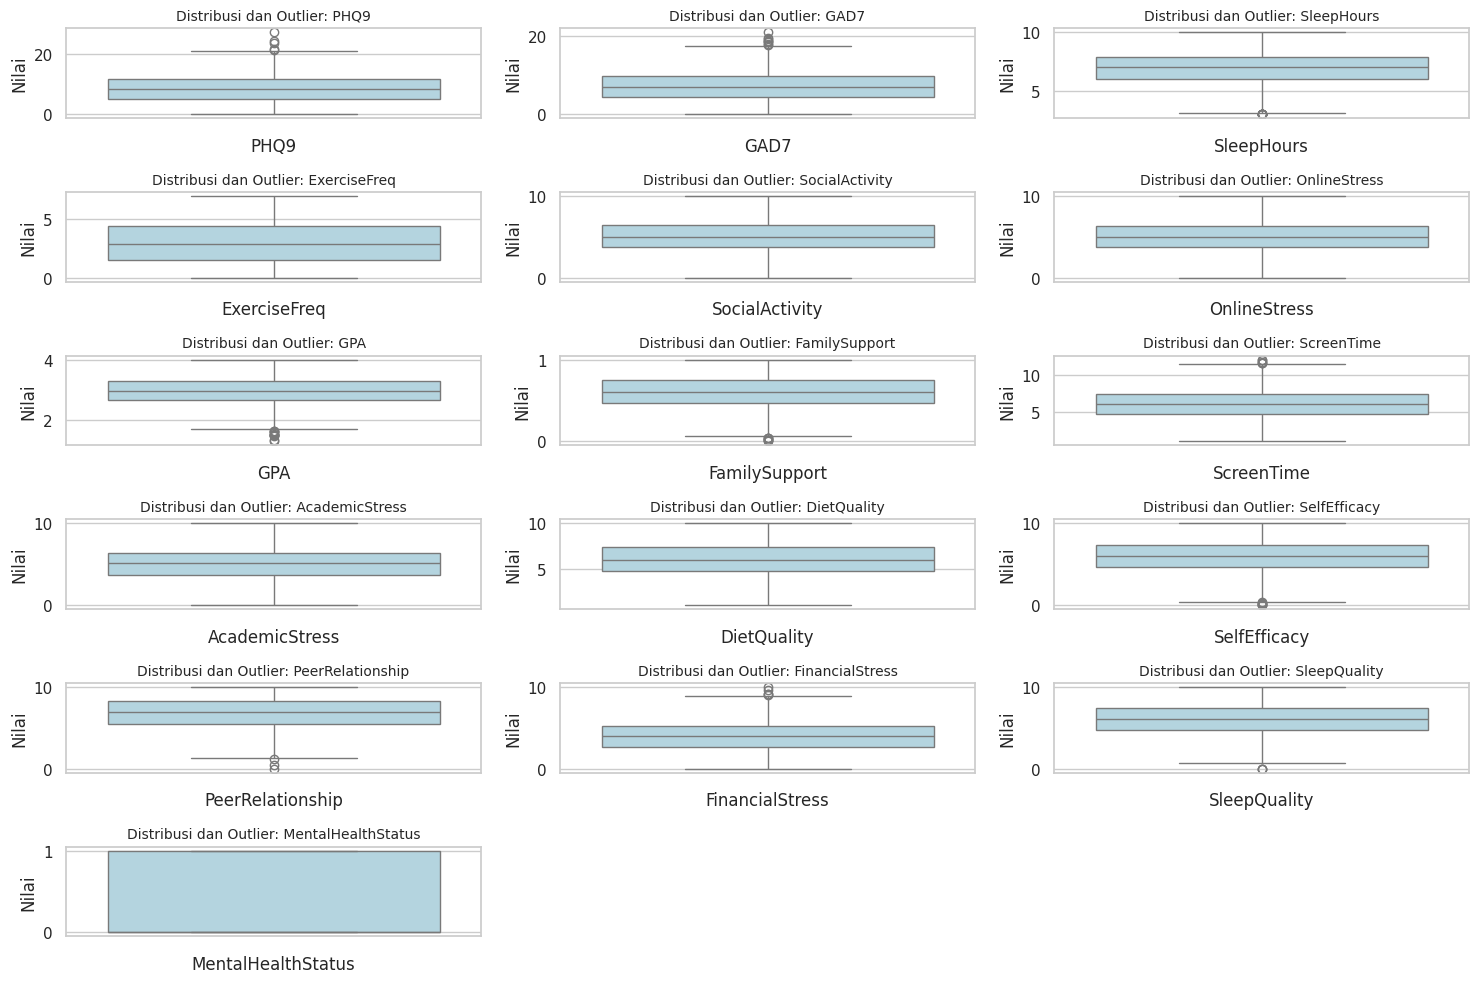

In [11]:
sns.set(style="whitegrid")

# Ambil semua kolom numerik
numeric_cols = df.select_dtypes(include=np.number).columns

# Tentukan layout grid
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

plt.figure(figsize=(15,10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)

    sns.boxplot(y=df[col], color='lightblue')

    plt.title(f'Distribusi dan Outlier: {col}', fontsize=10)
    plt.ylabel("Nilai")
    plt.xlabel(col)

plt.tight_layout()
plt.show()

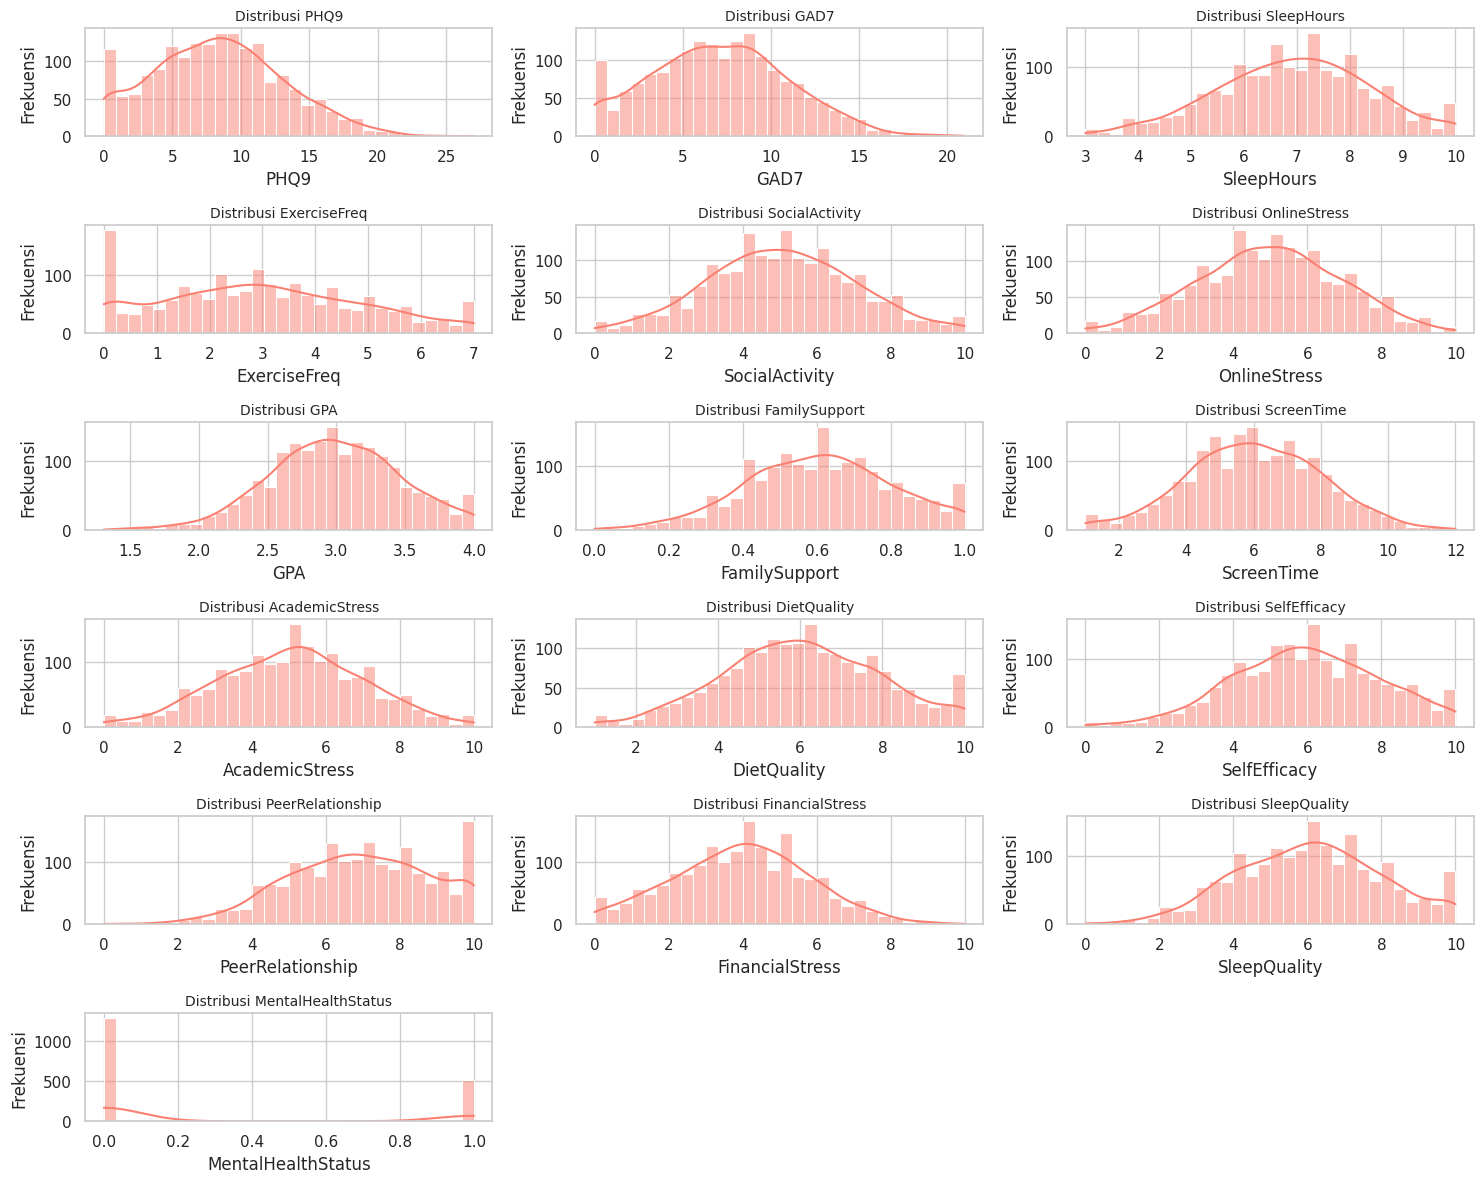

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")

# Ambil semua kolom numerik
numeric_cols = df.select_dtypes(include=np.number).columns

# Tentukan layout grid
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

plt.figure(figsize=(15, 12))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)

    sns.histplot(df[col], bins=30, kde=True, color='salmon')

    plt.title(f'Distribusi {col}', fontsize=10)
    plt.xlabel(col)
    plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()


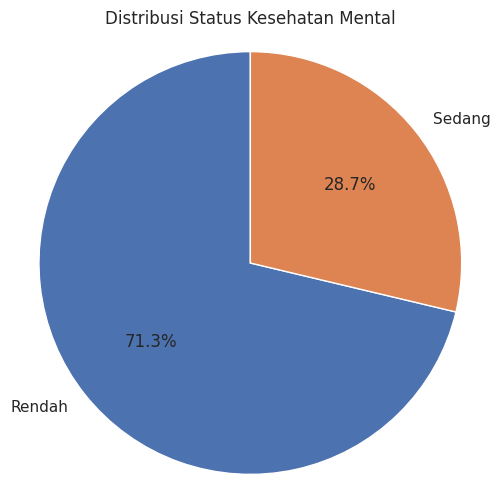

In [13]:
label_map = {
    0: 'Rendah',
    1: 'Sedang',
    2: 'Tinggi'
}

data = df['MentalHealthStatus'].value_counts()

labels = [label_map[i] for i in data.index]

plt.figure(figsize=(6,6))
plt.pie(data, labels=labels, autopct='%1.1f%%', startangle=90)

plt.title('Distribusi Status Kesehatan Mental')
plt.axis('equal')

plt.show()

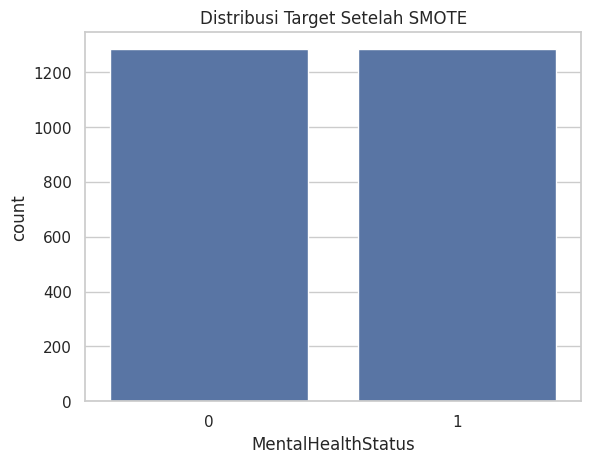

In [14]:
# Distribusi target
sns.countplot(x=y_final)
plt.title("Distribusi Target Setelah SMOTE")
plt.show()

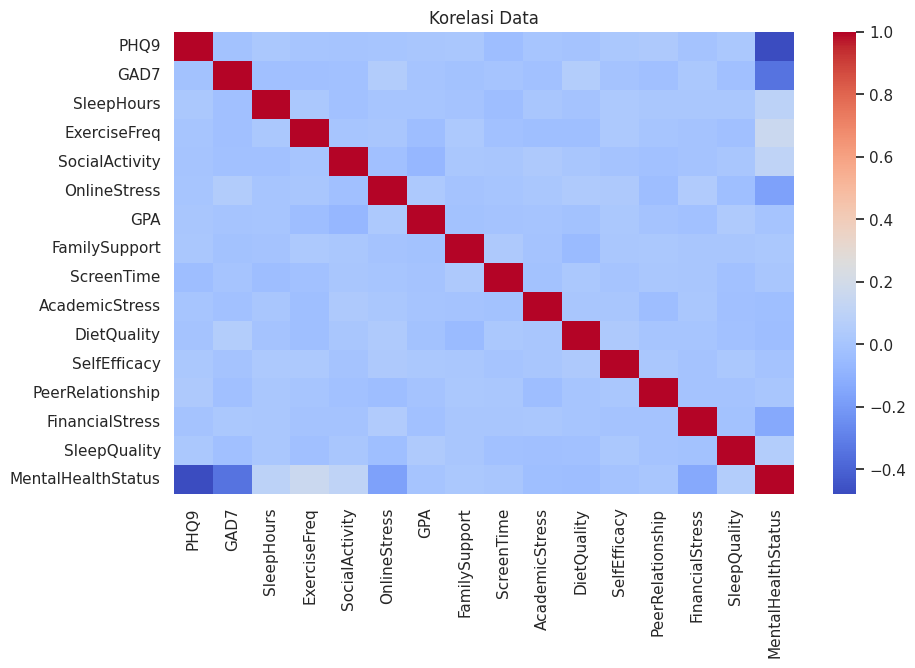

In [15]:
# Heatmap korelasi
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Korelasi Data")
plt.show()

**5. Data Splitting (3 Variasi)**

In [16]:
splits = {
    "70:30": train_test_split(X_final, y_final, test_size=0.3, random_state=42),
    "80:20": train_test_split(X_final, y_final, test_size=0.2, random_state=42),
    "90:10": train_test_split(X_final, y_final, test_size=0.1, random_state=42)
}

**6. Model + Hyperparameter Tuning**

In [17]:
results = []

for split_name, (X_train, X_test, y_train, y_test) in splits.items():

    print(f"\n===== SPLIT {split_name} =====")

    # =====================
    # 1. XGBOOST (PALING KUAT)
    # =====================
    xgb_param = {
        'n_estimators': [200, 300],
        'max_depth': [5, 10],
        'learning_rate': [0.05, 0.1],
        'subsample': [0.8, 1]
    }

    xgb = GridSearchCV(XGBClassifier(eval_metric='mlogloss'), xgb_param, cv=5)
    xgb.fit(X_train, y_train)

    y_pred_xgb = xgb.predict(X_test)
    acc_xgb = accuracy_score(y_test, y_pred_xgb)

    print("XGBoost:", acc_xgb)

    # =====================
    # 2. RANDOM FOREST
    # =====================
    rf_param = {
        'n_estimators': [200, 300],
        'max_depth': [10, 20, None]
    }

    rf = GridSearchCV(RandomForestClassifier(), rf_param, cv=5)
    rf.fit(X_train, y_train)

    y_pred_rf = rf.predict(X_test)
    acc_rf = accuracy_score(y_test, y_pred_rf)

    print("Random Forest:", acc_rf)

    # =====================
    # 3. SVM
    # =====================
    svm_param = {
        'C': [1, 10, 50],
        'kernel': ['rbf'],
        'gamma': ['scale']
    }

    svm = GridSearchCV(SVC(), svm_param, cv=5)
    svm.fit(X_train, y_train)

    y_pred_svm = svm.predict(X_test)
    acc_svm = accuracy_score(y_test, y_pred_svm)

    print("SVM:", acc_svm)

    # Simpan hasil
    results.append({
        'Split': split_name,
        'XGBoost': acc_xgb,
        'RandomForest': acc_rf,
        'SVM': acc_svm
    })

    # Evaluasi detail (XGBoost)
    print("\nConfusion Matrix XGBoost:")
    print(confusion_matrix(y_test, y_pred_xgb))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_xgb))



===== SPLIT 70:30 =====
XGBoost: 0.8922077922077922
Random Forest: 0.8844155844155844
SVM: 0.8857142857142857

Confusion Matrix XGBoost:
[[341  45]
 [ 38 346]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       386
           1       0.88      0.90      0.89       384

    accuracy                           0.89       770
   macro avg       0.89      0.89      0.89       770
weighted avg       0.89      0.89      0.89       770


===== SPLIT 80:20 =====
XGBoost: 0.9046692607003891
Random Forest: 0.8891050583657587
SVM: 0.8871595330739299

Confusion Matrix XGBoost:
[[232  29]
 [ 20 233]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.90       261
           1       0.89      0.92      0.90       253

    accuracy                           0.90       514
   macro avg       0.90      0.90      0.90       514
weighted avg       0.91      0.

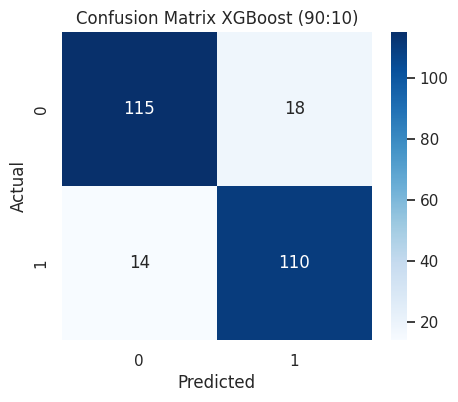

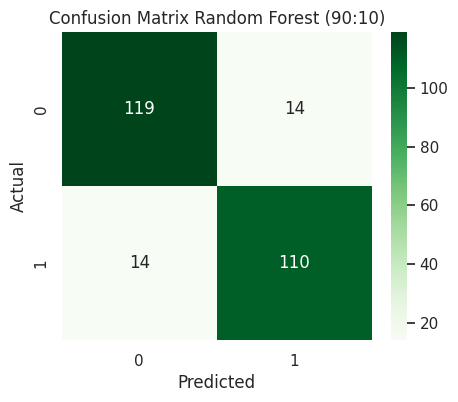

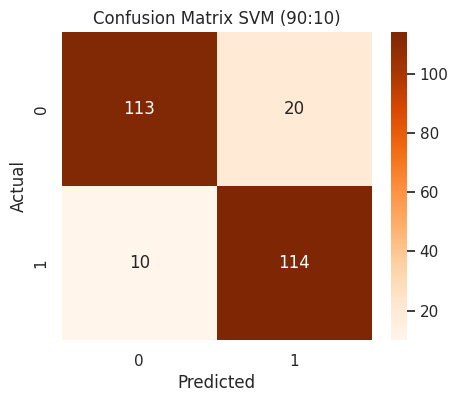

In [18]:
import seaborn as sns

# ======================
# 1. XGBOOST
# ======================
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')

plt.title(f'Confusion Matrix XGBoost ({split_name})')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()


# ======================
# 2. RANDOM FOREST
# ======================
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')

plt.title(f'Confusion Matrix Random Forest ({split_name})')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()


# ======================
# 3. SVM
# ======================
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges')

plt.title(f'Confusion Matrix SVM ({split_name})')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()


**7. Model Comparison**

   Split   XGBoost  RandomForest       SVM
0  70:30  0.892208      0.884416  0.885714
1  80:20  0.904669      0.889105  0.887160
2  90:10  0.875486      0.891051  0.883268


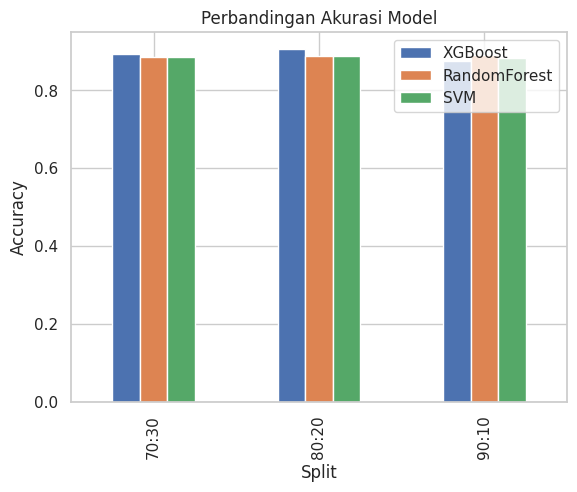

In [19]:
results_df = pd.DataFrame(results)
print(results_df)

results_df.set_index('Split').plot(kind='bar')
plt.title("Perbandingan Akurasi Model")
plt.ylabel("Accuracy")
plt.show()

### **Kesimpulan Performa Model Klasifikasi Kesehatan Mental**

Berdasarkan hasil pengujian menggunakan tiga algoritma (**XGBoost**, **Random Forest**, dan **SVM**) dengan tiga variasi pembagian data ($70:30$, $80:20$, dan $90:10$), diperoleh beberapa temuan utama sebagai berikut:

1.  **Model Terbaik Berdasarkan Akurasi Tertinggi**
    Model **XGBoost** pada variasi data splitting **$80:20$** berhasil mencatatkan akurasi tertinggi dibandingkan seluruh skenario lainnya, yaitu sebesar **$90,47\%$**. Hal ini menunjukkan bahwa kombinasi algoritma *gradient boosting* dengan proporsi data latih $80\%$ sangat optimal dalam mengenali pola indikator kesehatan mental mahasiswa.

2.  **Analisis Performa Tiap Algoritma**
    * **XGBoost**: Menunjukkan performa yang sangat kuat pada rasio $70:30$ ($89,22\%$) dan mencapai puncaknya pada $80:20$ ($90,47\%$). Namun, terjadi penurunan performa pada rasio $90:10$ ($87,55\%$), yang mengindikasikan sensitivitas model terhadap jumlah data uji yang terlalu sedikit.
    * **Random Forest**: Menunjukkan tren positif yang sangat stabil. Akurasi terus meningkat seiring bertambahnya data latih, mulai dari $88,44\%$ (pada $70:30$) hingga mencapai puncaknya sebesar **$89,11\%$** pada rasio **$90:10$**. Ini membuktikan bahwa Random Forest sangat tangguh (*robust*) terhadap variasi data.
    * **Support Vector Machine (SVM)**: Menampilkan performa yang paling konsisten dan stabil di angka **$88\%$**. Meskipun tidak mencapai angka $90\%$, SVM terbukti tidak mudah terpengaruh oleh perubahan rasio pembagian data, dengan rentang akurasi yang sempit antara $88,33\%$ hingga $88,72\%$.

3.  **Pemenuhan Target Performa**
    Seluruh algoritma yang diuji telah berhasil memenuhi kriteria keberhasilan proyek, yaitu mencapai akurasi di atas ambang batas minimal **$85\%$**.

**Rekomendasi Akhir:**
Untuk implementasi praktis, model **XGBoost dengan pembagian data $80:20$** direkomendasikan karena memberikan akurasi tertinggi ($90,47\%$). Namun, jika prioritas adalah kestabilan model terhadap penambahan data di masa depan, **Random Forest** merupakan alternatif yang sangat baik karena grafiknya yang terus meningkat secara konsisten.